In [113]:
import os.path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
from collections import defaultdict
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
file_name = '2026-01-21_6_latency.csv'

all_data = []


df = pd.read_csv(os.path.join('./result/metrics/',file_name))
provModels = df['provModel'].unique().tolist()
datasets = df['dataset'].unique().tolist()

# provModels = df['provModel'].unique().tolist()
# datasets = df['dataset'].unique().tolist()

for provModel in provModels:
    all_data = {
    }
    for dataset in datasets:
        scale_factors = [0.1]
        # scale_factors = df['scaleFactor'].unique().tolist()
        sf_data=[]
        for sf in scale_factors:
            dt_sf_prov = df[ (df['provModel']== provModel) & (df['dataset'] == dataset) & (df['scaleFactor'] == sf)][['query','mean']]

            orig = dt_sf_prov[dt_sf_prov['query'].str.startswith('orig_')].set_index('query')
            prov = dt_sf_prov[dt_sf_prov['query'].str.startswith('prov_')].set_index('query')

            orig.index = orig.index.str.replace('orig_', '')
            prov.index = prov.index.str.replace('prov_', '')

            comparison = orig.join(prov, lsuffix='_orig', rsuffix='_prov')
            sf_data.append((sf,comparison))
        all_data[dataset]=sf_data

    fig, ax = plt.subplots(figsize=(14, 6))

    bar_width = 0.35
    gap_queries = 0.2
    gap_sf = 1.0
    gap_dataset = 2.0

    x_positions = []
    query_labels = []

    current_x = 0

    sf_centers = []
    dataset_centers = []

    for dataset_name, sf_list in all_data.items():
        dataset_start = current_x

        for sf_idx, (sf, comparison) in enumerate(sf_list):
            n_queries = len(comparison)
            x_inner = np.arange(current_x, current_x + n_queries)

            # Store query ticks
            x_positions.extend(x_inner)
            query_labels.extend(comparison.index)

            # Plot bars
            ax.bar(x_inner - bar_width / 2, comparison['mean_orig'],
                   width=bar_width,
                   label='orig' if current_x == 0 else "")
            ax.bar(x_inner + bar_width / 2, comparison['mean_prov'],
                   width=bar_width,
                   label='prov' if current_x == 0 else "")

            # Scale factor center
            sf_centers.append((x_inner.mean(), sf))

            current_x += n_queries + gap_sf

        dataset_end = current_x - gap_sf
        dataset_centers.append(((dataset_start + dataset_end) / 2, dataset_name))
        current_x += gap_dataset

    # ---- Query ticks (level 1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(query_labels, rotation=45, ha='right')

    ax.set_ylabel('Mean Value')
    ax.set_title(f"{provModel} Provenance : Original vs Provenance Query Latencies")

    # ---- Scale factor labels (level 2)
    ymin, ymax = ax.get_ylim()
    sf_y = ymin - (ymax - ymin) * 0.08

    for x, sf in sf_centers:
        ax.text(x, sf_y, f'SF {sf}', ha='center', va='top', fontsize=10)

    # ---- Dataset labels (level 3)
    dataset_y = ymin - (ymax - ymin) * 0.15

    for x, name in dataset_centers:
        ax.text(x, dataset_y, name, ha='center', va='top',
                fontsize=11, fontweight='bold')

    # ---- Layout
    plt.subplots_adjust(bottom=0.30)
    ax.legend()
    plt.show()




AttributeError: Can only use .str accessor with string values!

In [8]:

file_name = '2026-01-21_1_latency.csv'

def query_number(qid):
    """
    Extract numeric suffix from query id, e.g. finbench-15 -> 15
    """
    m = re.search(r"-(\d+(?:\.\d+)?)$", qid)
    return float(m.group(1)) if m else float("inf")


def make_tables(filename):
    groups = defaultdict(lambda: defaultdict(dict))

    with open(os.path.join('./result/metrics/',file_name), newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            dataset = row["dataset"]
            scale = row["scaleFactor"]
            prov_model = row["provModel"]
            query = row["query"]
            mean = float(row["mean"])
            if "hitRate" in row.keys():
                hit_rate = float(row["hitRate"])
            else:
                hit_rate = "N/A"

            if query.startswith("orig_"):
                qid = query.replace("orig_", "")
                groups[(dataset, scale, prov_model)][qid]["orig"] = mean
                groups[(dataset, scale, prov_model)][qid]["hit_rate"] = hit_rate
            elif query.startswith("prov_"):
                qid = query.replace("prov_", "")
                groups[(dataset, scale, prov_model)][qid]["prov"] = mean
                groups[(dataset, scale, prov_model)][qid]["hit_rate"] = hit_rate

    # Print tables sorted by query number
    for (dataset, scale, prov_model), queries in sorted(groups.items()):
        print(f"\nDataset: {dataset}, ScaleFactor: {scale}, ProvModel: {prov_model}")
        print(f"{'Query':<15} {'Orig Mean':>12} {'Prov Mean':>12} {'Hit Rate':>12} {'% Change':>12}")
        print("-" * 60)

        for qid in sorted(queries.keys(), key=query_number):
            vals = queries[qid]
            orig = vals.get("orig")
            prov = vals.get("prov")
            hitRate = vals.get("hit_rate")

            if orig is not None and prov is not None:
                pct = ((prov - orig) / orig) * 100
                pct_str = f"{pct:.2f}%"
                orig_str = f"{orig:.4f}"
                prov_str = f"{prov:.4f}"
            else:
                pct_str = "N/A"
                orig_str = f"{orig:.4f}" if orig is not None else "N/A"
                prov_str = f"{prov:.4f}" if prov is not None else "N/A"

            print(f"{qid:<15} {orig_str:>12} {prov_str:>12} {hitRate:>12} {pct_str:>12}")

make_tables(file_name)


Dataset: finbench, ScaleFactor: 0.1, ProvModel: How
Query              Orig Mean    Prov Mean     Hit Rate     % Change
------------------------------------------------------------
finbench-1         1056.0716    1076.0884          N/A        1.90%
finbench-2           72.6139     198.3647          N/A      173.18%
finbench-3          149.2435     175.7076          N/A       17.73%
finbench-4          160.7637     303.6370          N/A       88.87%
finbench-5          173.1746     258.5841          N/A       49.32%
finbench-6          160.0881     214.7878          N/A       34.17%
finbench-7          116.8651     549.4201          N/A      370.13%
finbench-8          170.7741     558.6754          N/A      227.14%
finbench-9           84.8842     112.0775          N/A       32.04%
finbench-10          54.5332      73.2104          N/A       34.25%
finbench-11          54.5482      72.9620          N/A       33.76%
finbench-12         150.0343     156.1674          N/A        4.09%
fi

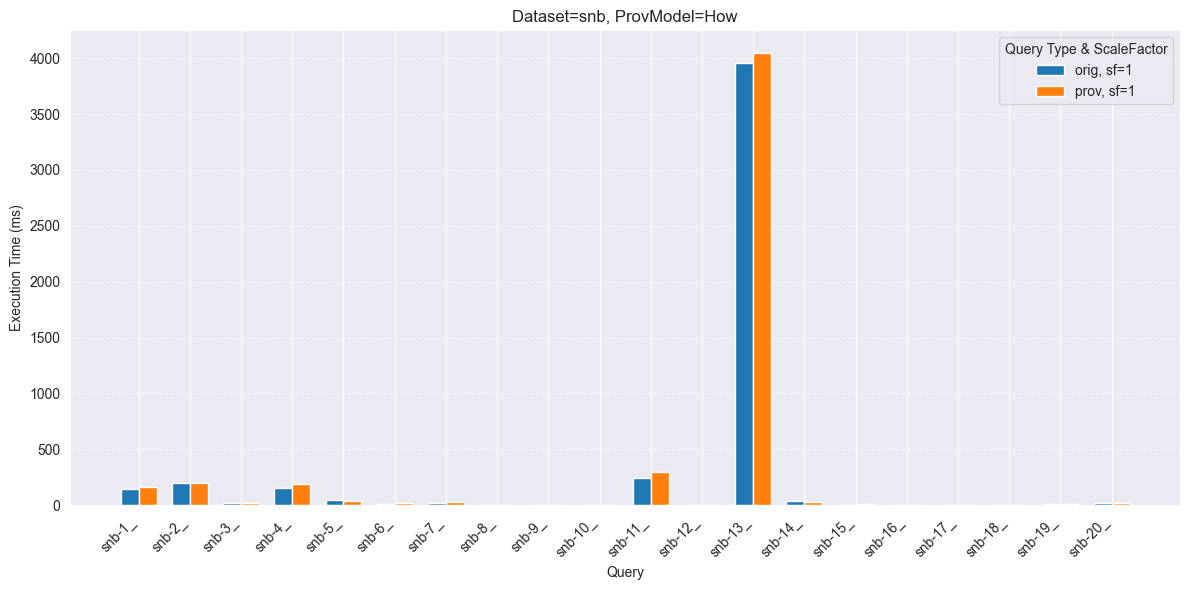

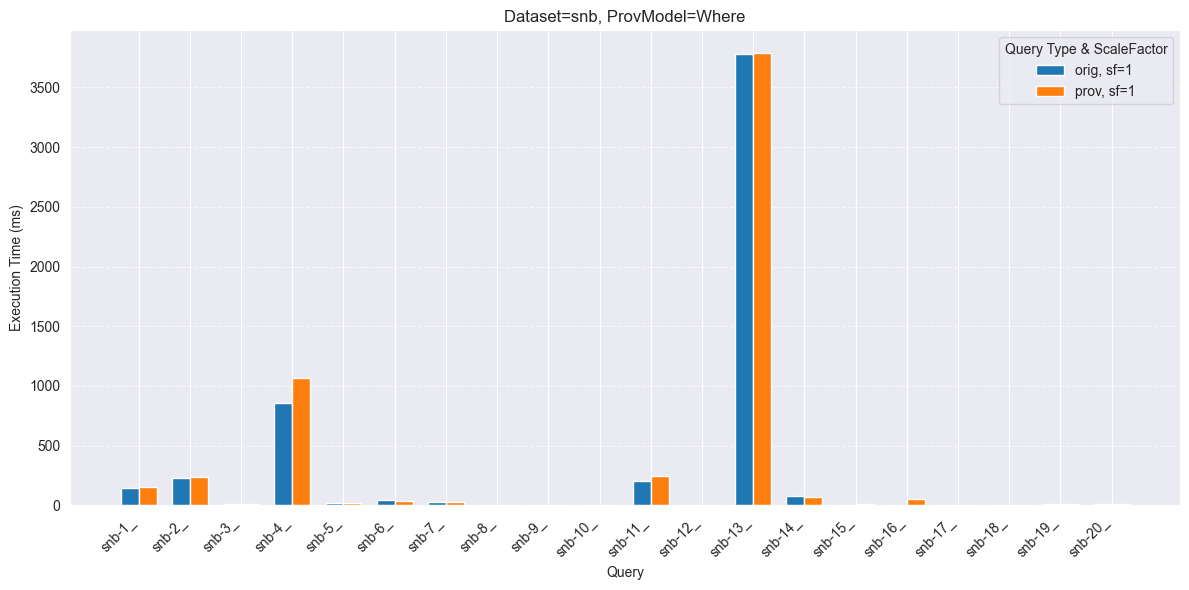

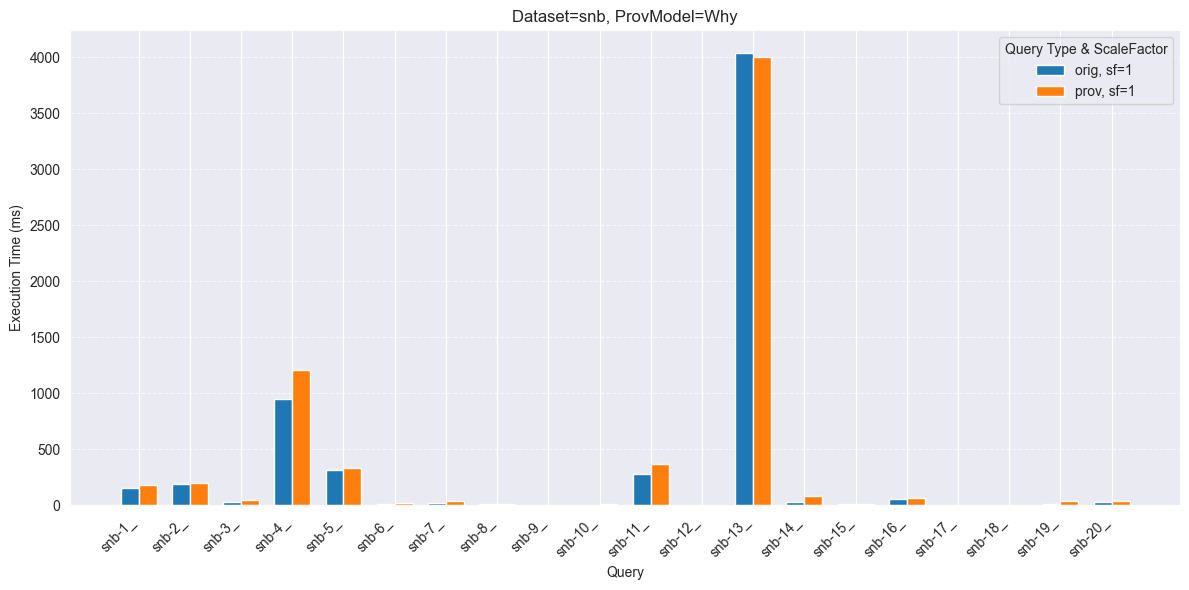

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# Load CSV
file_name = '2026-01-22_test-snbbi_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")

# Extract base query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)
df = df[df["base_query"]!="finbench-7.4_"]

# Apply scaling
df["adjusted_mean"] = df["mean"] * 10
agg = (
    df.groupby(["dataset", "scaleFactor", "provModel", "base_query", "query_type"])
    .agg(total_mean=("adjusted_mean", "sum"))
    .reset_index()
)
agg["total_mean"] /= 100

# Sort by query number
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")

agg["query_num"] = agg["base_query"].apply(query_number)
agg = agg.sort_values("query_num")

datasets = agg["dataset"].unique()
prov_models = agg["provModel"].unique()
scale_factors = sorted(agg["scaleFactor"].unique())

for ds in datasets:
    for pm in prov_models:
        subset = agg[(agg["dataset"] == ds) & (agg["provModel"] == pm)]

        plt.figure(figsize=(12,6))

        x_labels = subset["base_query"].unique()
        x = np.arange(len(x_labels))
        n_sf = len(scale_factors)
        width = 0.35 / n_sf  # small enough for orig+prov per scaleFactor

        for i, sf in enumerate(scale_factors):
            sf_data = subset[subset["scaleFactor"] == sf].set_index("base_query").loc[x_labels]

            # Plot orig and prov side by side
            plt.bar(x - width/2 + i*width, sf_data[sf_data["query_type"]=="orig"]["total_mean"],
                    width=width, color="tab:blue", label=f"orig, sf={sf}" if i==0 else "")
            plt.bar(x + width/2 + i*width, sf_data[sf_data["query_type"]=="prov"]["total_mean"],
                    width=width, color="tab:orange", label=f"prov, sf={sf}" if i==0 else "")

        plt.xticks(x, x_labels, rotation=45, ha="right")
        plt.xlabel("Query")
        plt.ylabel("Execution Time (ms)")
        plt.title(f"Dataset={ds}, ProvModel={pm}")
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Remove duplicate legend entries
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), title="Query Type & ScaleFactor")

        plt.tight_layout()
        plt.show()


In [111]:
file_name = '2026-01-22_test-snbbi_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")

# Extract base query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

param_mean = df.groupby([
    "dataset", "scaleFactor", "provModel",
    "query_type", "base_query", "parameter"
])["resultSize"].mean().reset_index()

dataset_success = (
    param_mean.groupby([
        "dataset", "scaleFactor", "provModel",
        "query_type", "base_query"
    ])
    .apply(lambda g: (g["resultSize"] > 0).mean())
    .reset_index(name="success_ratio")
)

dataset_success[dataset_success["success_ratio"]==0]

/var/folders/ll/x2qgpx8s7nq02qgm1pfftv6w0000gn/T/ipykernel_43334/1483053769.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  param_mean.groupby([


,dataset,scaleFactor,provModel,query_type,base_query,success_ratio
0,snb,1,How,orig,snb-10_,0.0
2,snb,1,How,orig,snb-12_,0.0
4,snb,1,How,orig,snb-14_,0.0
5,snb,1,How,orig,snb-15_,0.0
18,snb,1,How,orig,snb-8_,0.0
20,snb,1,How,prov,snb-10_,0.0
22,snb,1,How,prov,snb-12_,0.0
24,snb,1,How,prov,snb-14_,0.0
25,snb,1,How,prov,snb-15_,0.0
38,snb,1,How,prov,snb-8_,0.0


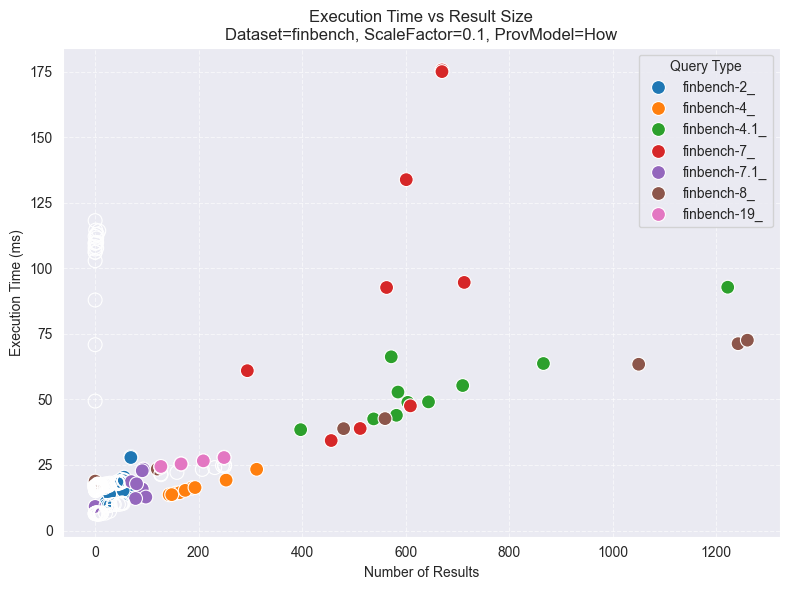

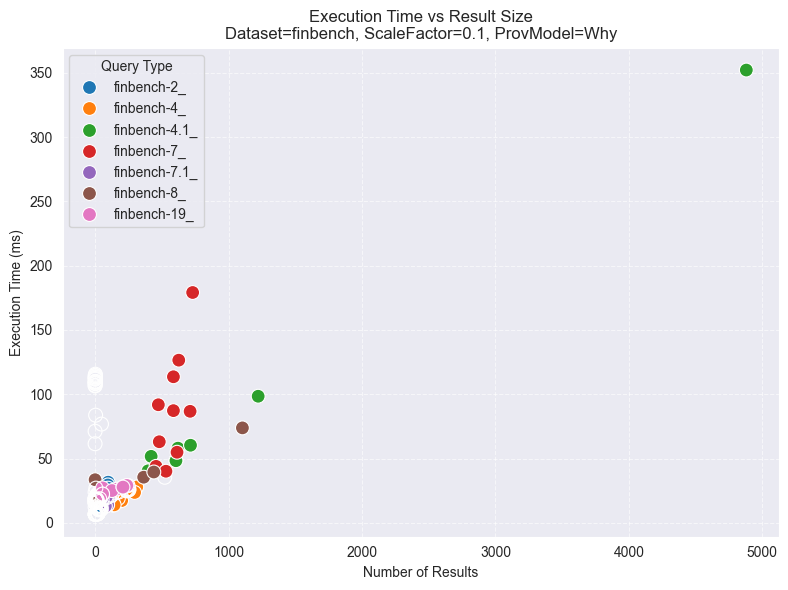

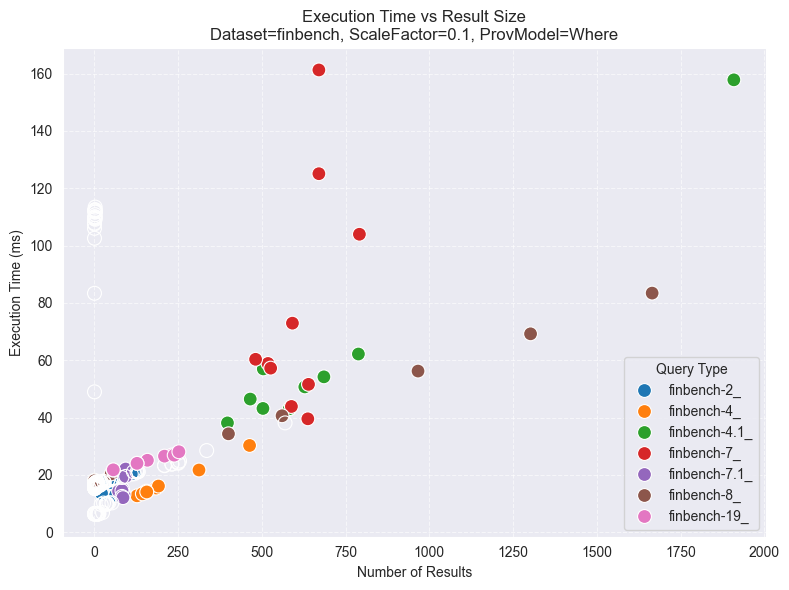

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import re
import numpy as np

# Load CSV
file_name = '2026-01-21_7-with-4n7-alt-1_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")
df= df[df["query_type"]=="prov"]

# Extract base query name
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

# df = df[df["base_query"].isin([
#                                 "finbench-2_",
#                                # "finbench-3_",
#                                "finbench-4_",
#                                "finbench-7_",
#                                "finbench-8_",
#                                "finbench-19_"
# ])]

df["adjusted_mean"] = df["mean"]  # or apply any scaling if needed
df["adjusted_results"] = df["resultSize"]

# agg = (
#     df.groupby(["dataset", "scaleFactor", "provModel", "base_query", "query_type"])
#     .agg(total_mean=("adjusted_mean", "sum"), total_results=("resultSize", "sum"))
#     .reset_index()
# )
#
# agg["total_mean"] /= 100
# agg["total_results"] /= 100

# Sort by query number
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")
# agg["query_num"] = agg["base_query"].apply(query_number)
# agg = agg.sort_values("query_num")
df["query_num"] = df["base_query"].apply(query_number)
df = df.sort_values("query_num")

# --- Scatter plot per provModel/dataset/scaleFactor ---
datasets = df["dataset"].unique()
scale_factors = df["scaleFactor"].unique()
prov_models = df["provModel"].unique()

for ds in datasets:
    for sf in scale_factors:
        for pm in prov_models:
            subset = df[
                (df["dataset"]==ds) &
                (df["scaleFactor"]==sf) &
                (df["provModel"]==pm)
                ]
            plt.figure(figsize=(8,6))
            sns.scatterplot(
                data=subset,
                x="adjusted_results",
                y="adjusted_mean",
                hue="base_query",
                hue_order=[
                    "finbench-2_",
                    # "finbench-3_",
                    "finbench-4_",
                    "finbench-4.1_",
                    "finbench-7_",
                    "finbench-7.1_",
                    "finbench-8_",
                    "finbench-19_"
                ],
                # ["orig", "prov"],
                s=100  # marker size
            )
            plt.title(f"Execution Time vs Result Size\nDataset={ds}, ScaleFactor={sf}, ProvModel={pm}")
            plt.xlabel("Number of Results")
            plt.ylabel("Execution Time (ms)")
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend(title="Query Type")
            plt.tight_layout()
            plt.show()


In [33]:
import pandas as pd
import re

file_name = '2026-01-25_fnb_0.3_naive_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))
# Extract base_query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

# Mark hits
df["hit"] = df["resultSize"] > 0

# Calculate hit rate per query (can also group by dataset/scaleFactor/provModel)
hitrate = (
    df.groupby(["dataset", "scaleFactor", "provModel", "base_query"])
    .agg(
        hits=("hit", "sum"),
        total=("hit", "count")
    )
    .reset_index()
)

# Add hit rate column
hitrate["hit_rate"] = hitrate["hits"] / hitrate["total"]

# Sort by query number extracted from base_query
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")

hitrate["query_num"] = hitrate["base_query"].apply(query_number)
hitrate = hitrate.sort_values(["provModel","query_num"])

# Keep only relevant columns
hitrate = hitrate[["dataset","scaleFactor","provModel","base_query","hit_rate"]]

hitrate


,dataset,scaleFactor,provModel,base_query,hit_rate
0,finbench,0.3,How,finbench-1.1.1_,0.00
1,finbench,0.3,How,finbench-1.1_,0.00
2,finbench,0.3,How,finbench-1.2_,0.00
3,finbench,0.3,How,finbench-1.3_,0.00
4,finbench,0.3,How,finbench-1.4_,0.00
...,...,...,...,...,...
113,finbench,0.3,Why,finbench-16_,1.00
114,finbench,0.3,Why,finbench-17_,0.00
115,finbench,0.3,Why,finbench-18_,0.95
116,finbench,0.3,Why,finbench-19_,0.90


/Users/kouganepola/Documents/gql-provenance/experiments
Saved plot to ./result/plots/execution_time_Why.png


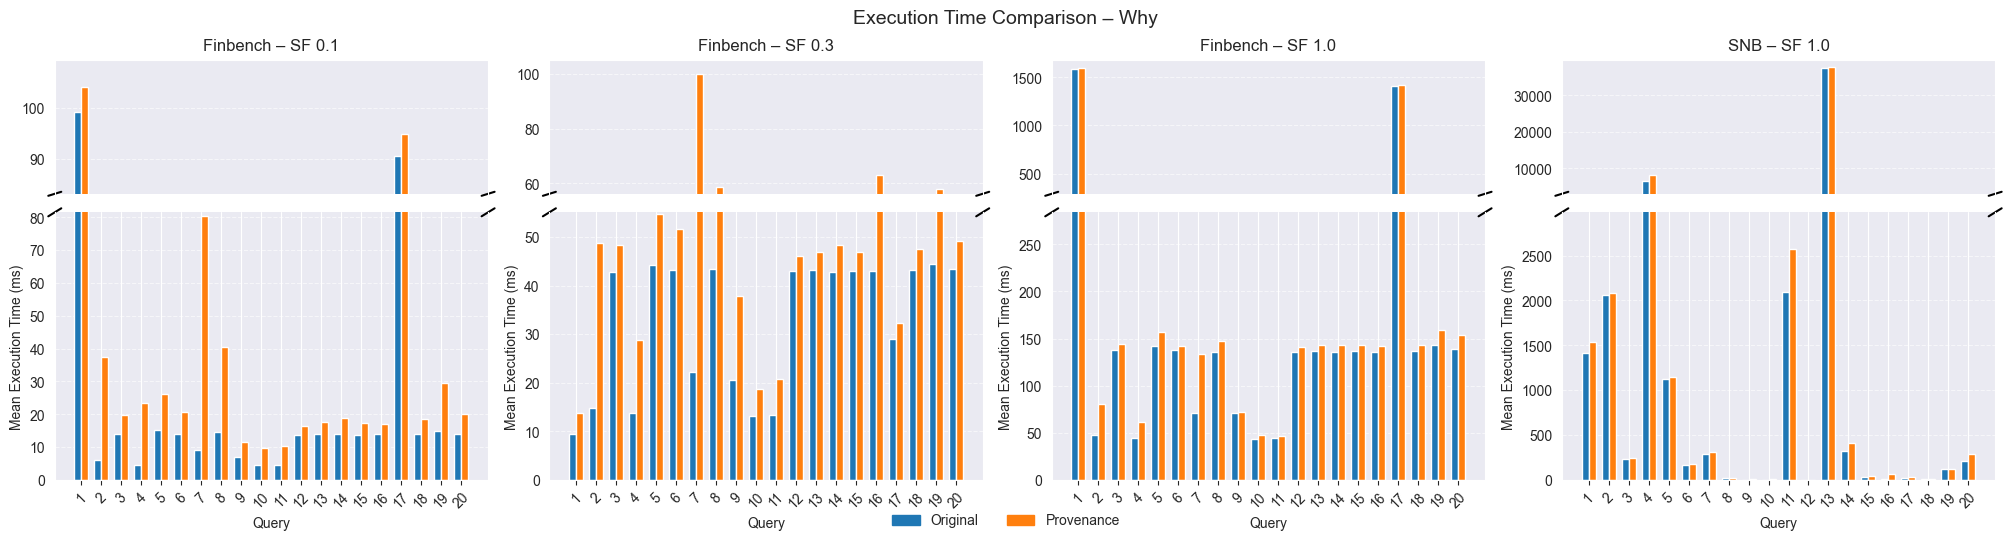

/Users/kouganepola/Documents/gql-provenance/experiments
Saved plot to ./result/plots/execution_time_Where.png


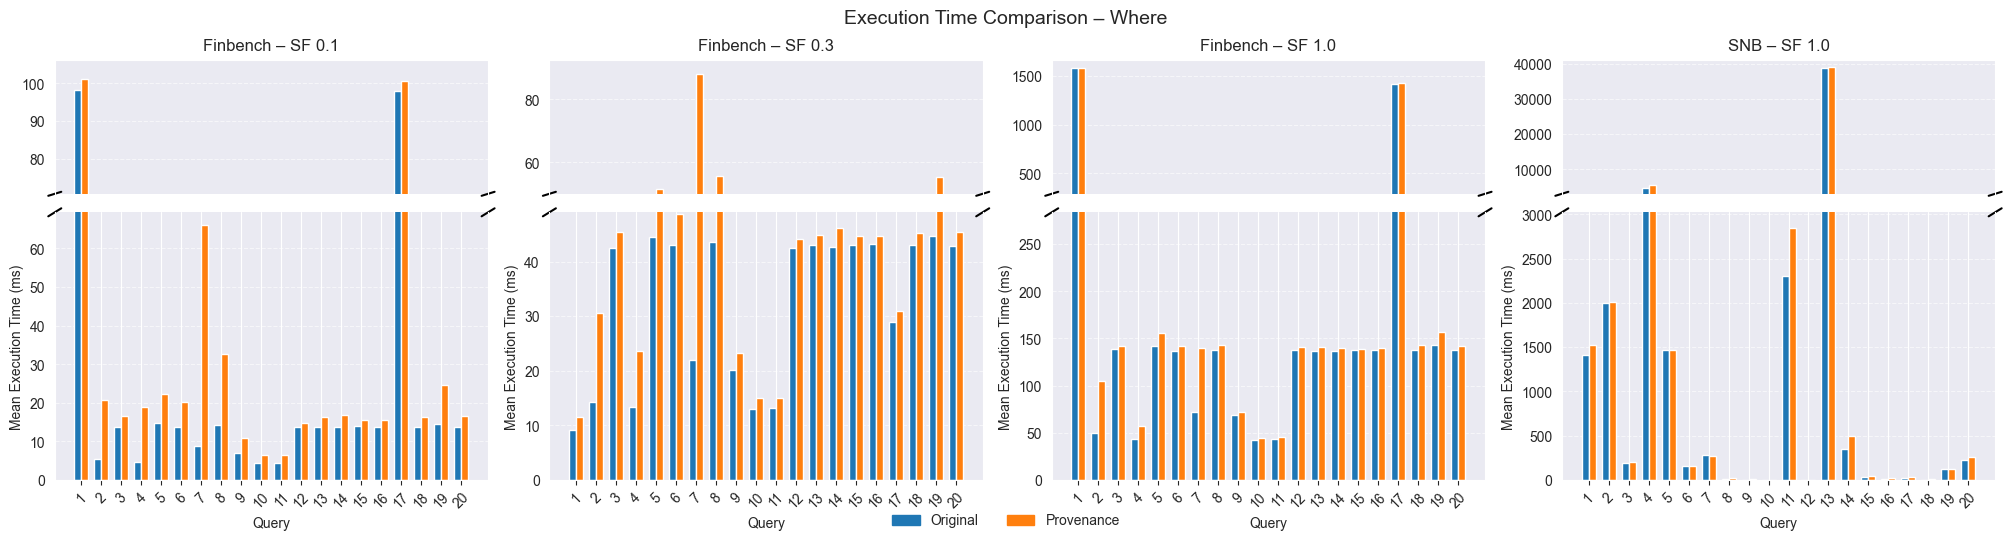

/Users/kouganepola/Documents/gql-provenance/experiments
Saved plot to ./result/plots/execution_time_How.png


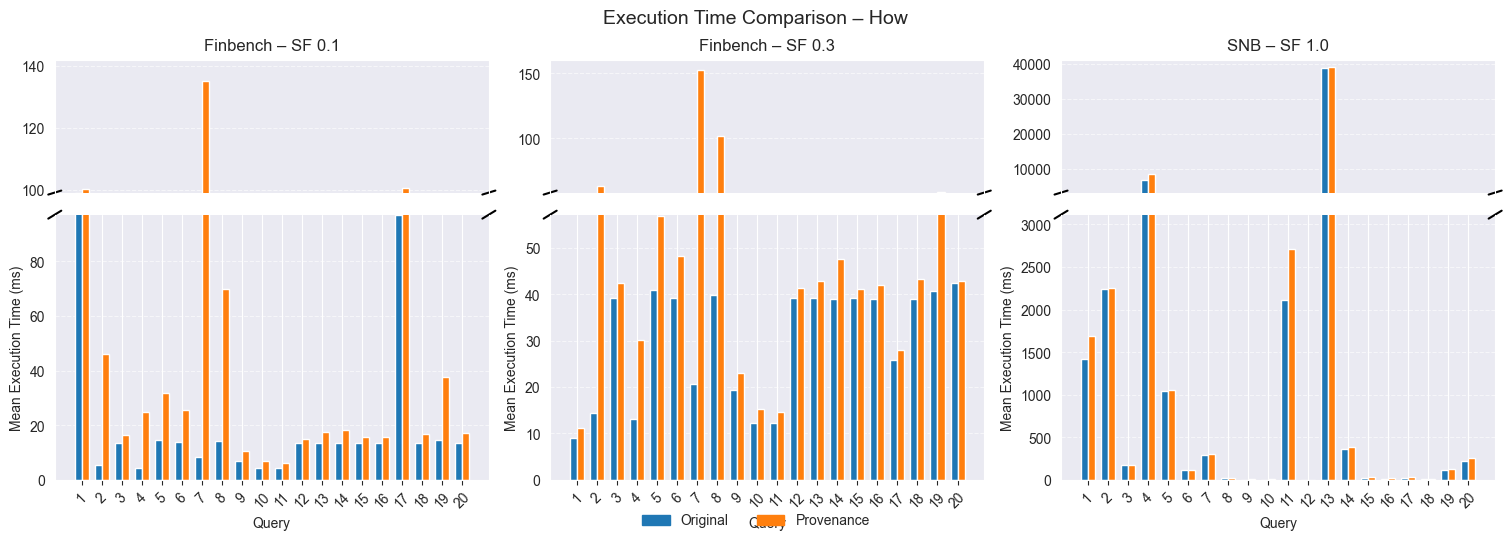

In [183]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

files = [
    "2026-01-25_naive_latency.csv",
    "2026-01-25_fnb_0.3_naive_latency.csv",
    "2026-01-25_fnb_1_naive_latency.csv",
    "2026-01-25_snb_1_naive_latency.csv"
]

df = pd.concat([pd.read_csv(os.path.join("result/metrics", f)) for f in files], ignore_index=True)

# Extract query_type
df["query_type"] = df["query"].str.extract(r'^(prov|orig)')

# Extract the query number after either "finbench-" or "sub-"
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_')

# Keep only integers or decimals ending in .3
df = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]

# Rename .3 queries to integer part
df["query_id"] = df["query_id"].str.replace(r"\.3$", "", regex=True)
df["query_id"] = df["query_id"].astype(int)

# Map dataset names to nicer titles
dataset_mapping = {
    "finbench": "Finbench",
    "snb": "SNB"
}

df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])

agg = (
    df.groupby(["provModel", "dataset","scaleFactor", "query_id", "query_type"], as_index=False)
    .agg(mean_exec_time=("mean", "mean"))
)

ORIG_COLOR = "#1f77b4"
PROV_COLOR = "#ff7f0e"

# Define the order of provenance models
prov_order = ["Why", "Where", "How"]

for prov_model in prov_order:
    if prov_model not in agg["provModel"].values:
        continue  # skip if this provenance model is not in the data

    sub_model = agg[agg["provModel"] == prov_model]

    # Sort by dataset, then scaleFactor
    sub_model_sorted = sub_model.sort_values(["dataset", "scaleFactor"])
    dataset_scale_order = sub_model_sorted[["dataset","scaleFactor"]].drop_duplicates().values
    n_scales = len(dataset_scale_order)

    fig = plt.figure(figsize=(5*n_scales, 5), constrained_layout=True)
    gs = GridSpec(2, n_scales, height_ratios=[1,2], hspace=0.05, figure=fig)

    for i, (dataset, scale) in enumerate(dataset_scale_order):
        sub = sub_model[(sub_model["dataset"]==dataset) & (sub_model["scaleFactor"]==scale)].sort_values("query_id")
        queries = sub["query_id"].unique()
        x = np.arange(len(queries))
        bar_width = 0.35

        orig = sub[sub["query_type"]=="orig"].set_index("query_id").reindex(queries)["mean_exec_time"]
        prov = sub[sub["query_type"]=="prov"].set_index("query_id").reindex(queries)["mean_exec_time"]

        # Determine split for broken axis
        SPLIT_LOW = np.percentile(pd.concat([orig, prov]), 90)
        SPLIT_HIGH = max(orig.max(), prov.max()) * 1.05

        # ----------------- Top axes -----------------
        ax_top = fig.add_subplot(gs[0, i])
        ax_top.bar(x - bar_width/2, orig, bar_width, color=ORIG_COLOR)
        ax_top.bar(x + bar_width/2, prov, bar_width, color=PROV_COLOR)
        ax_top.set_ylim(SPLIT_LOW*1.02, SPLIT_HIGH)
        ax_top.spines['bottom'].set_visible(False)
        ax_top.grid(axis='y', linestyle='--', alpha=0.6)

        # Remove any x-axis ticks and labels on top axes
        ax_top.set_xticks([])
        ax_top.set_xticklabels([])
        ax_top.tick_params(bottom=False)

        # Add dataset and scale text above the top axes
        ax_top.text(
            0.5, 1.05, f"{dataset} – SF {scale}", transform=ax_top.transAxes,
            ha='center', va='bottom', fontsize=12
        )

        # ----------------- Bottom axes -----------------
        ax_bottom = fig.add_subplot(gs[1, i])
        ax_bottom.bar(x - bar_width/2, orig, bar_width, color=ORIG_COLOR)
        ax_bottom.bar(x + bar_width/2, prov, bar_width, color=PROV_COLOR)
        ax_bottom.set_ylim(0, SPLIT_LOW)
        ax_bottom.spines['top'].set_visible(False)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(queries, rotation=45)
        ax_bottom.set_xlabel("Query")
        ax_bottom.set_ylabel("Mean Execution Time (ms)")
        ax_bottom.grid(axis='y', linestyle='--', alpha=0.6)
        ax_bottom.tick_params(bottom=True)

        # ----------------- Diagonal break markers -----------------
        d = 0.015
        ax_top.plot((-d, +d), (-d, +d), transform=ax_top.transAxes, color='k', clip_on=False)
        ax_top.plot((1-d, 1+d), (-d, +d), transform=ax_top.transAxes, color='k', clip_on=False)
        ax_bottom.plot((-d, +d), (1-d, 1+d), transform=ax_bottom.transAxes, color='k', clip_on=False)
        ax_bottom.plot((1-d, 1+d), (1-d, 1+d), transform=ax_bottom.transAxes, color='k', clip_on=False)

    # ----------------- Legend and figure title -----------------
    orig_patch = mpatches.Patch(color=ORIG_COLOR, label="Original")
    prov_patch = mpatches.Patch(color=PROV_COLOR, label="Provenance")

    # Add legend to the figure
    fig.legend(handles=[orig_patch, prov_patch], loc='lower center', ncol=2, frameon=False)
    fig.suptitle(f"Execution Time Comparison – {prov_model}", fontsize=14, y=1.05)

    import os
    print(os.getcwd())
    output_dir = "./result/plots"
    os.makedirs(output_dir, exist_ok=True)  # make sure folder exists

    filename = f"{output_dir}/execution_time_{prov_model}.png"
    fig.savefig(
        filename,
        dpi=300,        # resolution
        bbox_inches='tight'  # make sure labels and legends fit
    )
    print(f"Saved plot to {filename}")
    plt.show()


Saved plot to ./result/plots/execution_time_Why_Major1.png


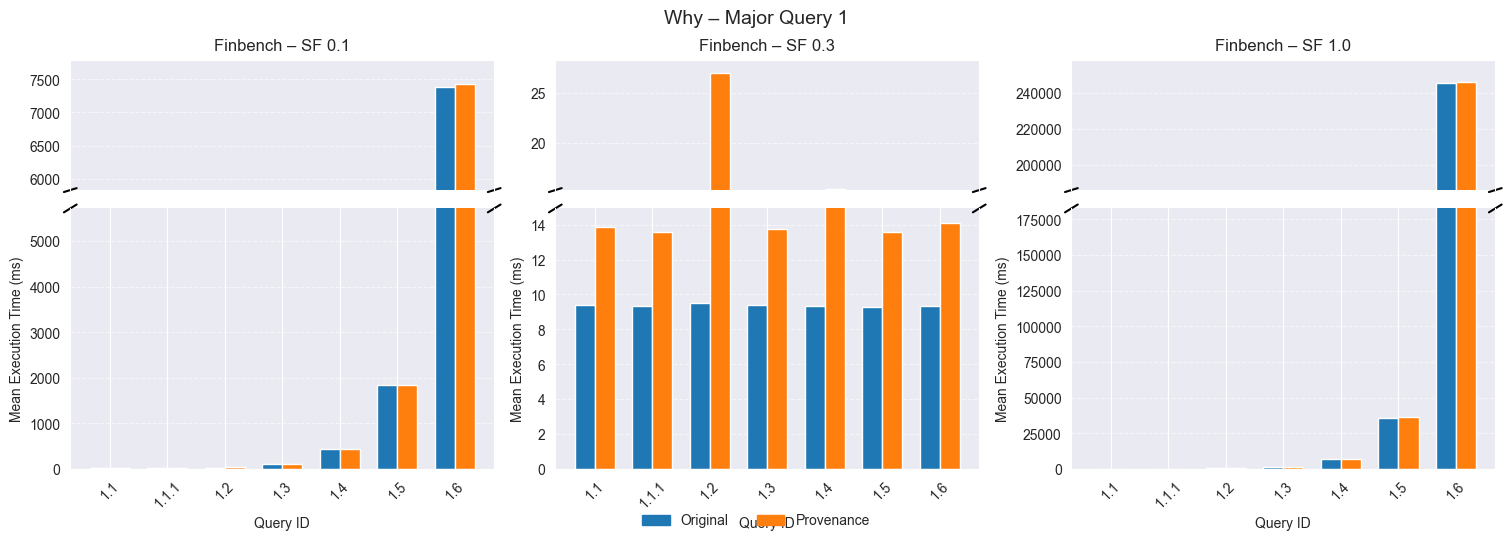

Saved plot to ./result/plots/execution_time_Why_Major2.png


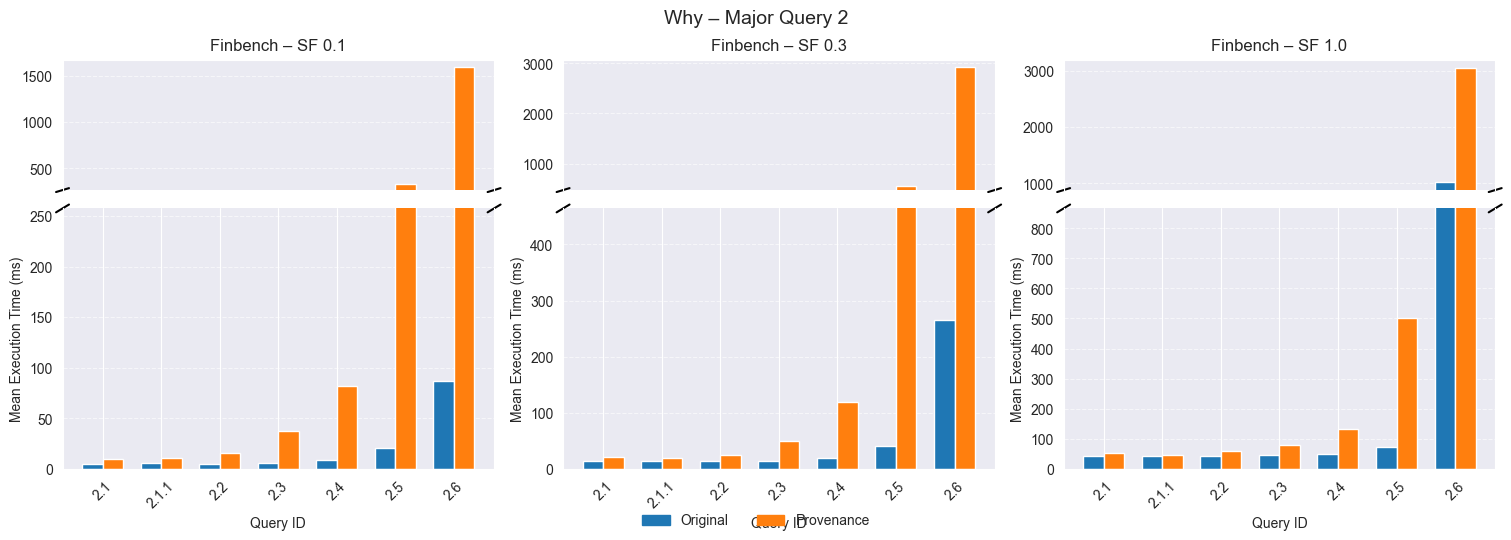

Saved plot to ./result/plots/execution_time_Why_Major4.png


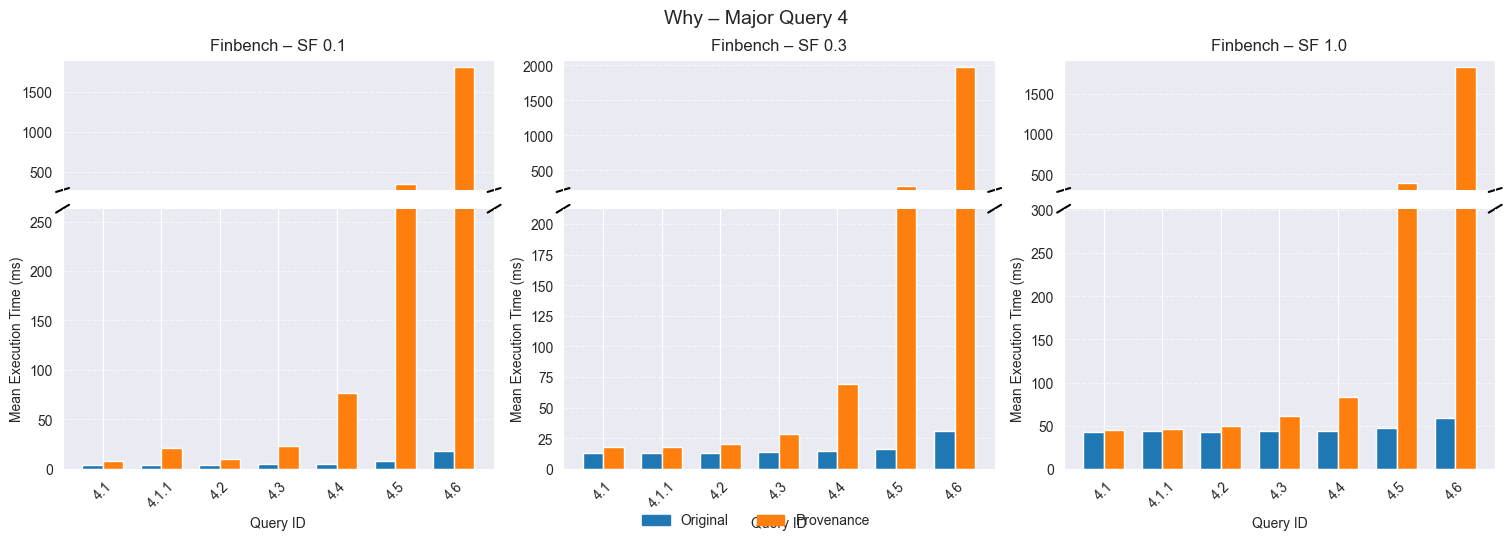

Saved plot to ./result/plots/execution_time_Why_Major7.png


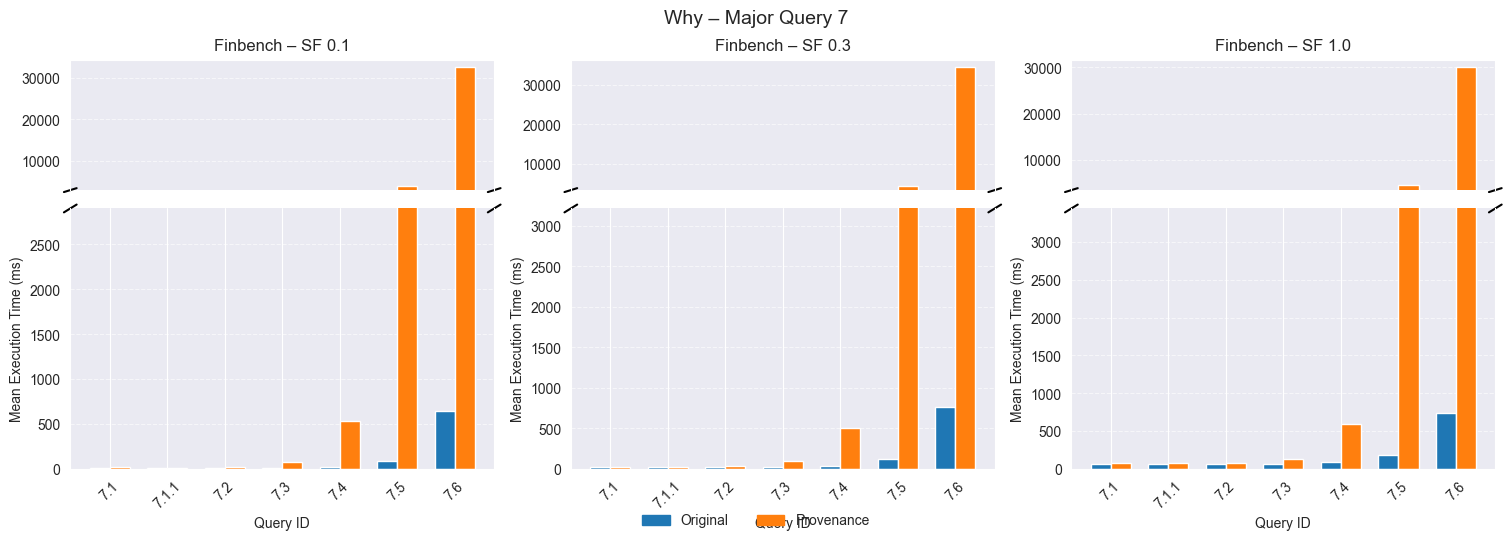

Saved plot to ./result/plots/execution_time_Why_Major9.png


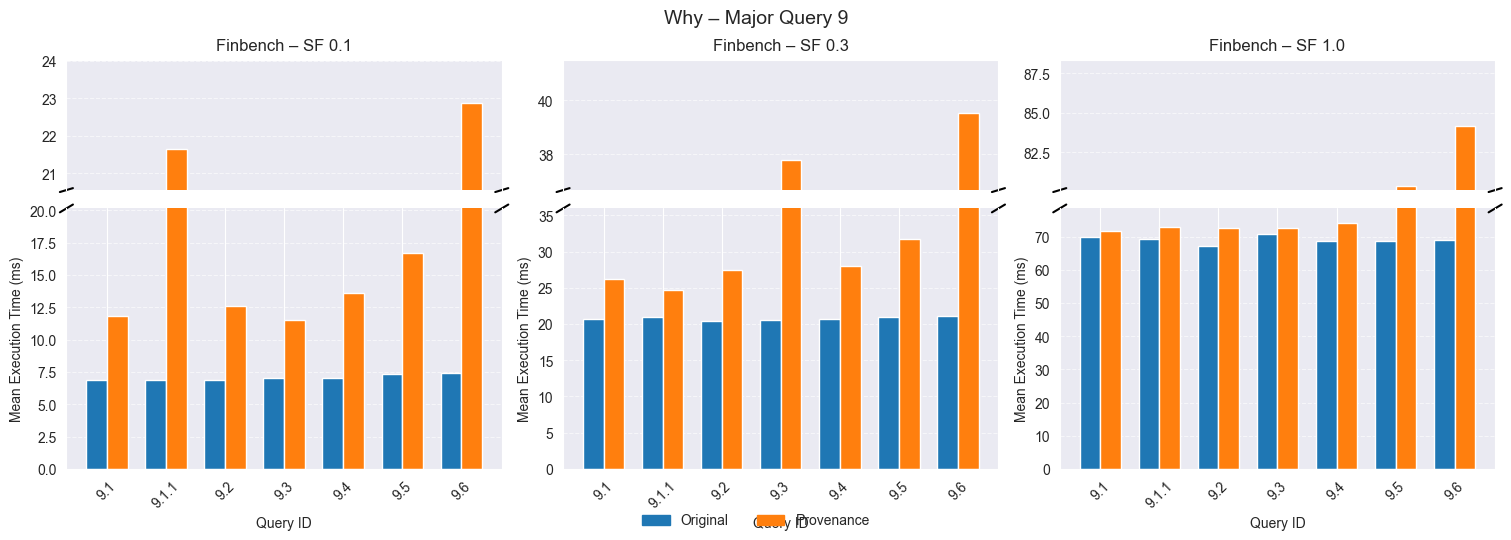

Saved plot to ./result/plots/execution_time_Where_Major1.png


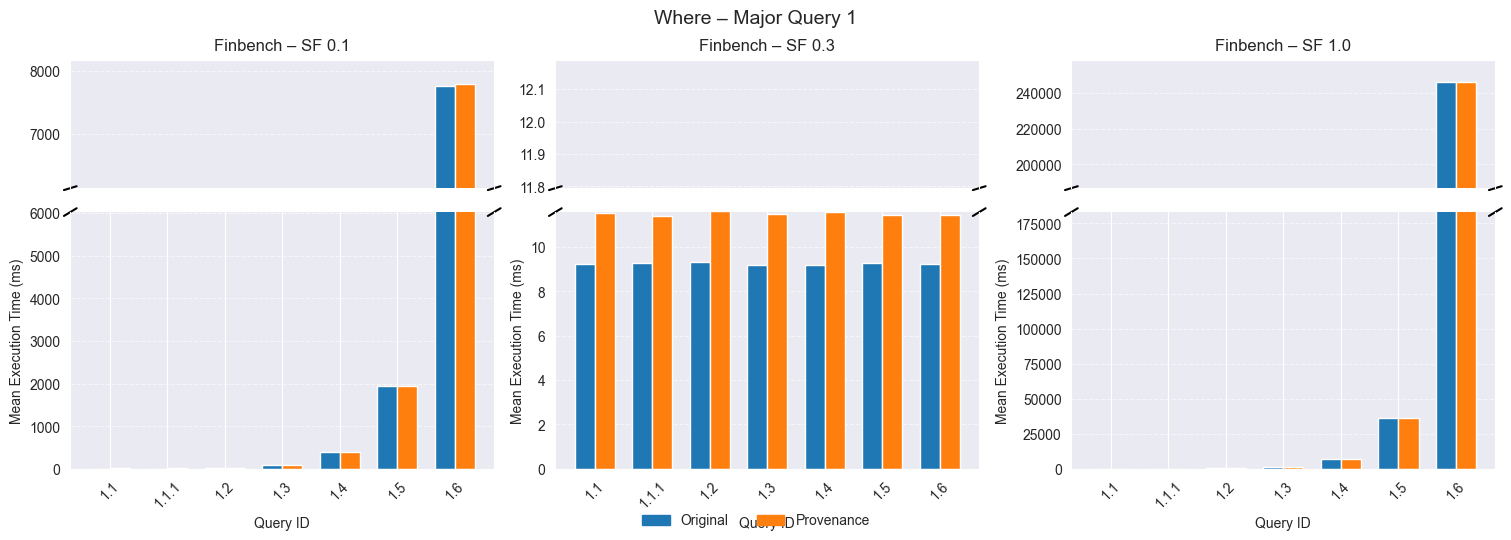

Saved plot to ./result/plots/execution_time_Where_Major2.png


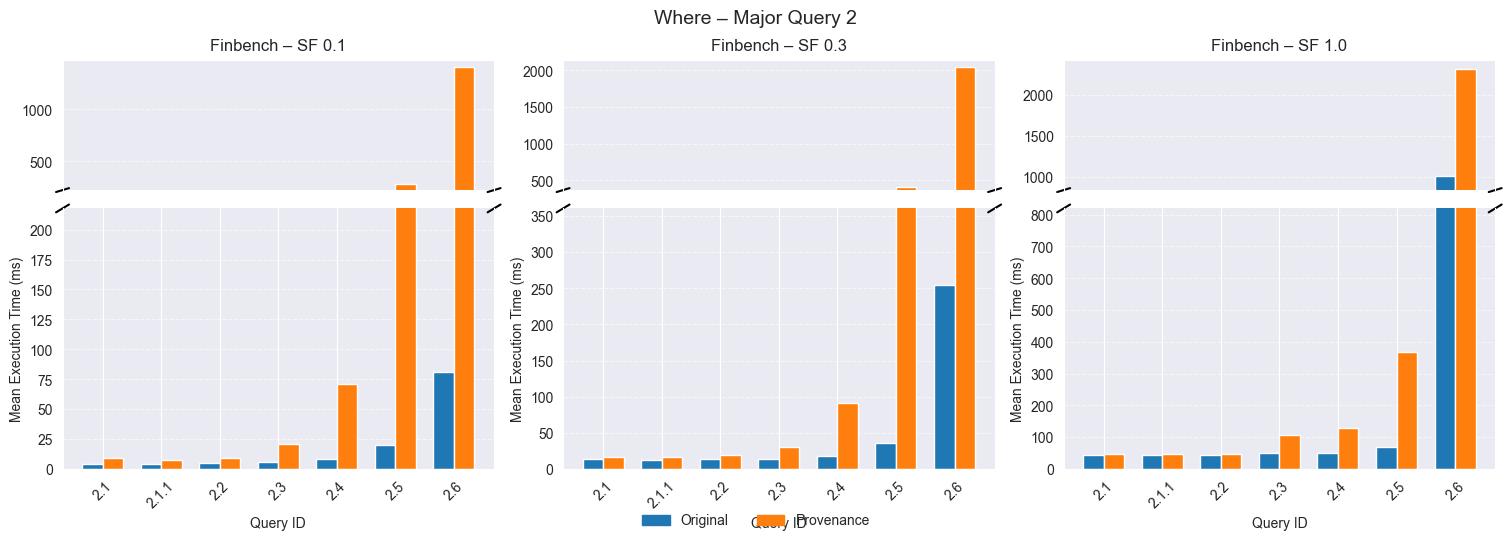

Saved plot to ./result/plots/execution_time_Where_Major4.png


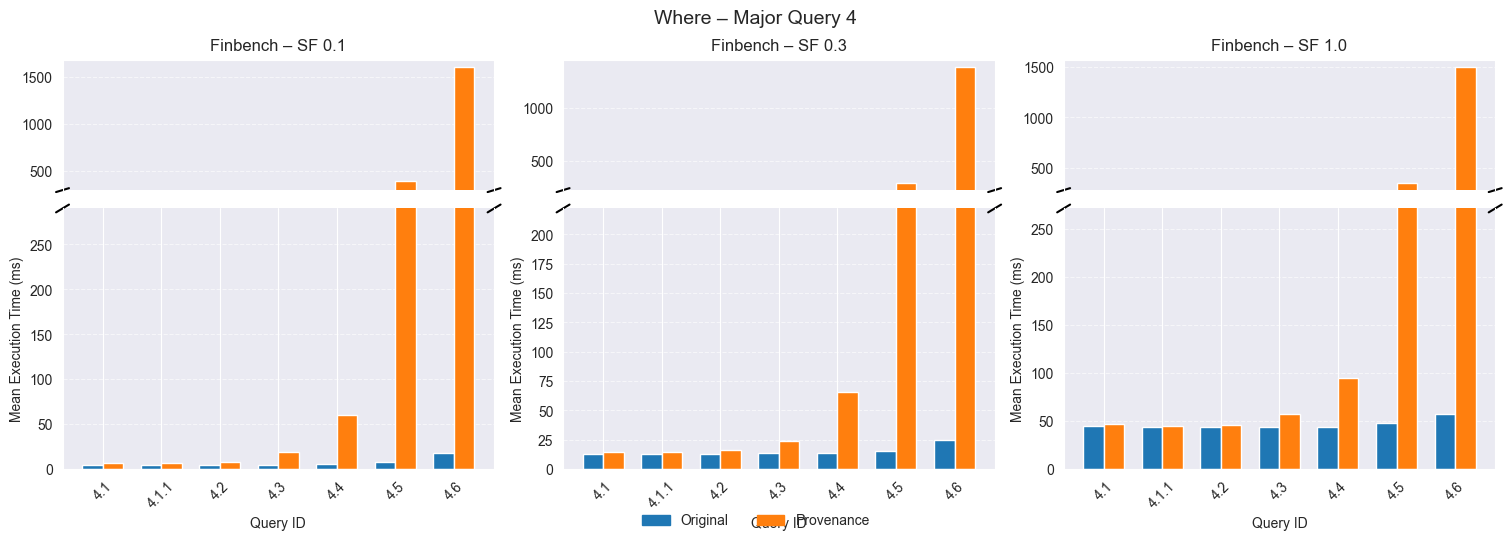

Saved plot to ./result/plots/execution_time_Where_Major7.png


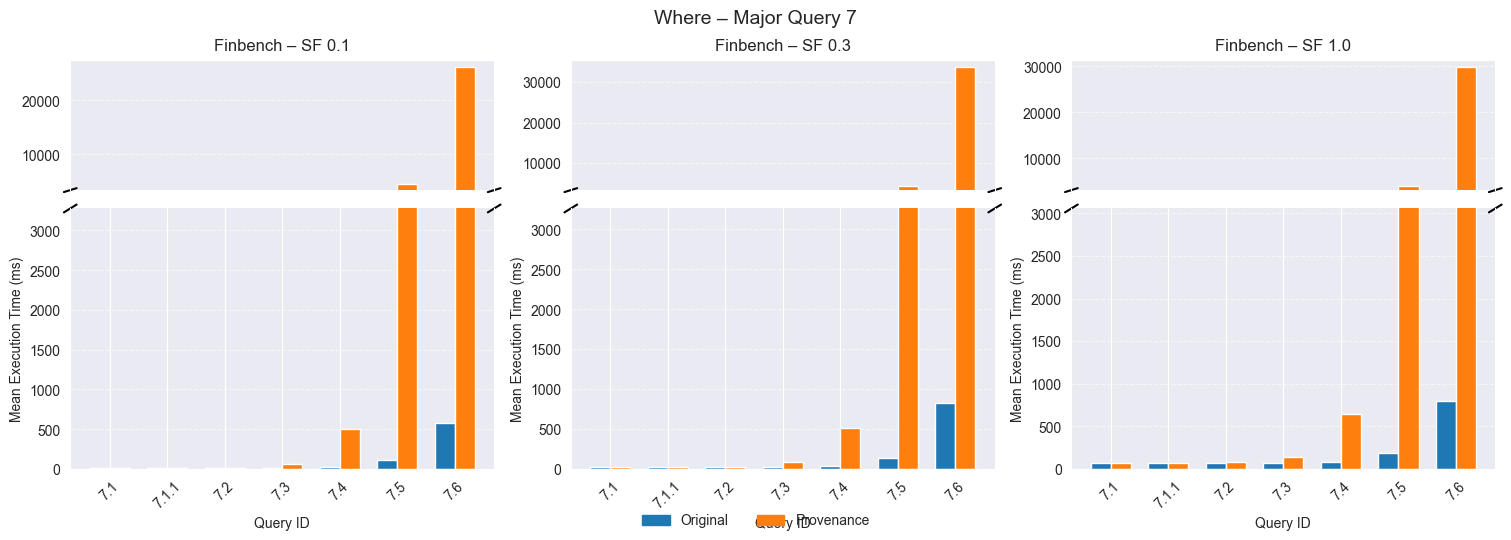

Saved plot to ./result/plots/execution_time_Where_Major9.png


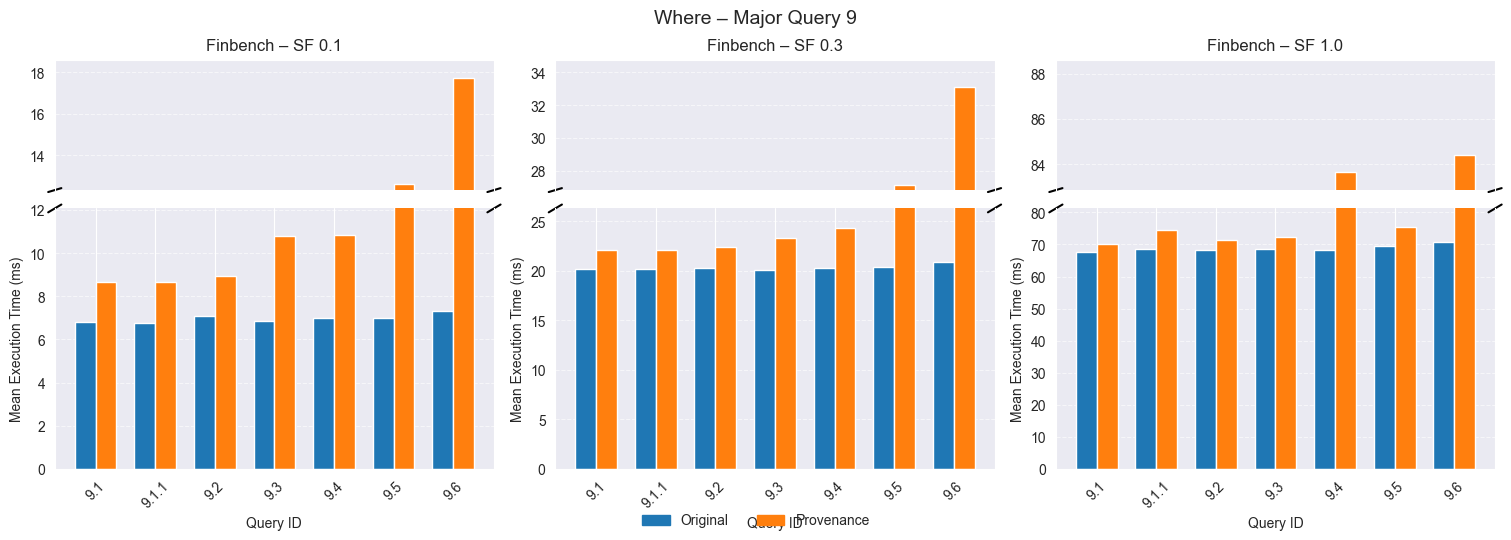

Saved plot to ./result/plots/execution_time_How_Major1.png


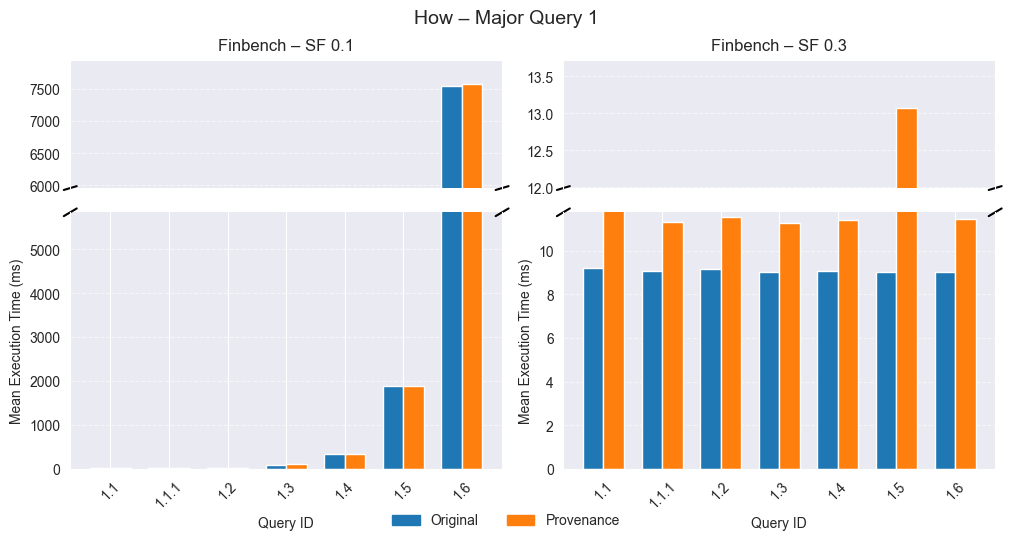

Saved plot to ./result/plots/execution_time_How_Major2.png


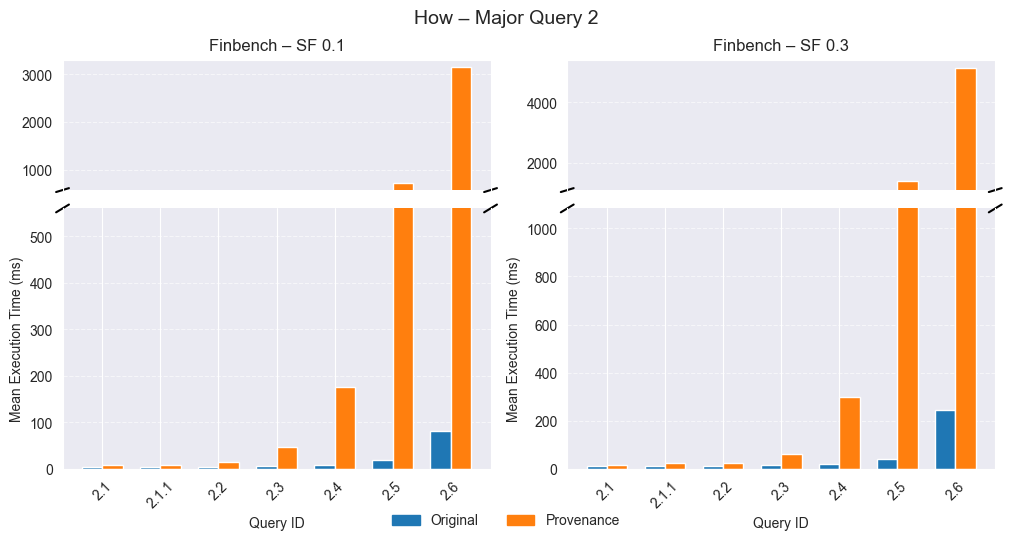

Saved plot to ./result/plots/execution_time_How_Major4.png


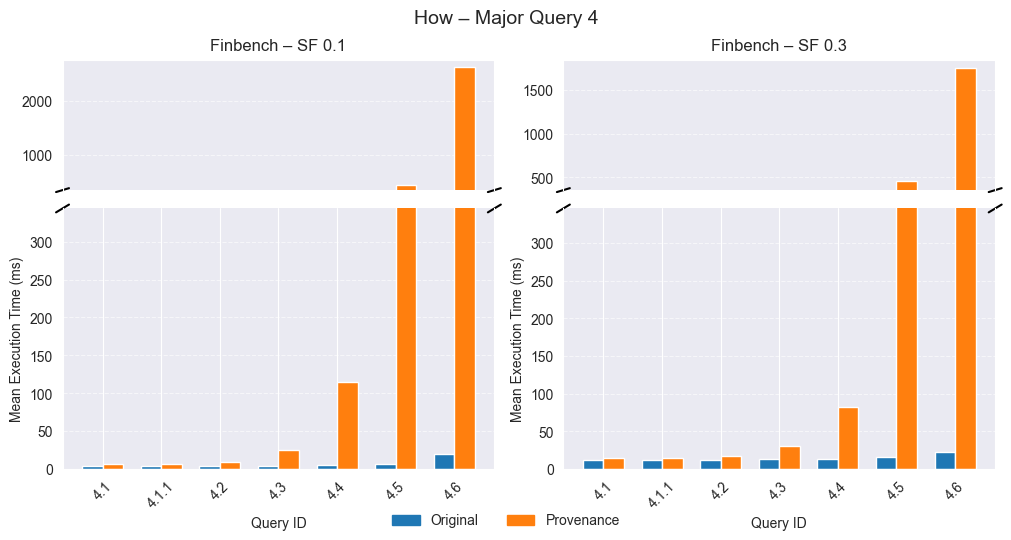

Saved plot to ./result/plots/execution_time_How_Major7.png


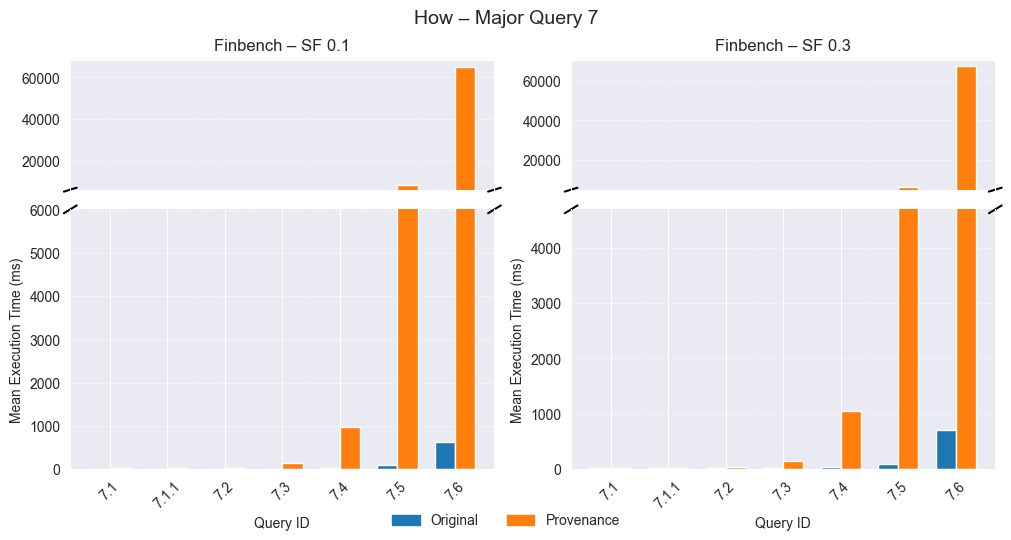

Saved plot to ./result/plots/execution_time_How_Major9.png


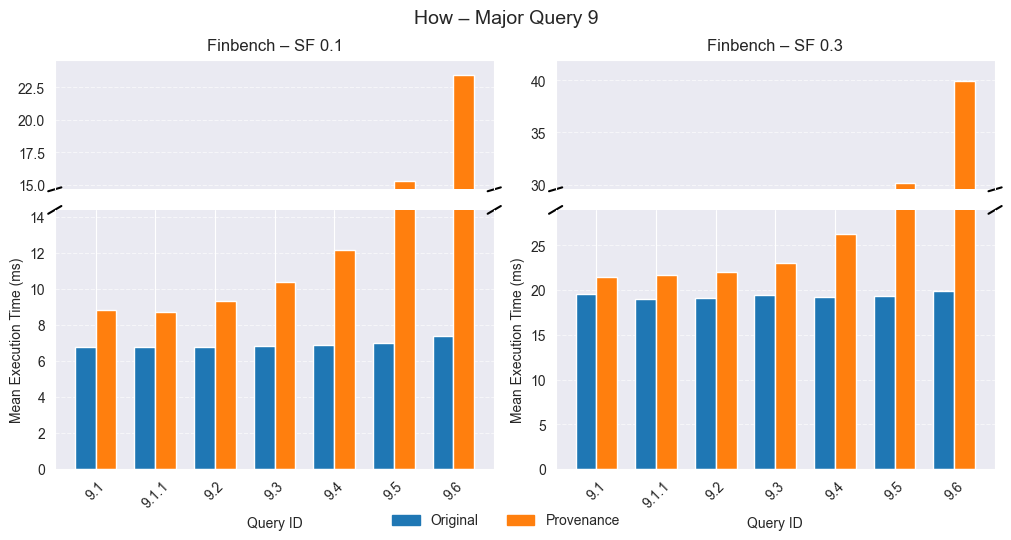

In [188]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

files = [
    "2026-01-25_naive_latency.csv",
    "2026-01-25_fnb_0.3_naive_latency.csv",
    "2026-01-25_fnb_1_naive_latency.csv"
]

df = pd.concat([pd.read_csv(os.path.join("result/metrics", f)) for f in files], ignore_index=True)

df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_')

# Keep only queries with decimals
df = df[df["query_id"].str.contains(r'\d+\.\d')].copy()

# Major query (first number before the dot)
df["query_major"] = df["query_id"].str.extract(r'^(\d+)')[0].astype(int)

# Map dataset names
dataset_mapping = {"finbench": "Finbench", "snb": "SNB"}
df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])

agg = (
    df.groupby(["provModel", "dataset", "scaleFactor", "query_major", "query_id", "query_type"], as_index=False)
    .agg(mean_exec_time=("mean", "mean"))
)

ORIG_COLOR = "#1f77b4"
PROV_COLOR = "#ff7f0e"
prov_order = ["Why", "Where", "How"]

for prov_model in prov_order:
    if prov_model not in agg["provModel"].values:
        continue

    sub_model = agg[agg["provModel"] == prov_model]

    # All major queries
    major_queries = sorted(sub_model["query_major"].unique())

    for major in major_queries:
        sub_major = sub_model[sub_model["query_major"] == major]

        # Sort by dataset + scaleFactor
        ds_sf_order = sub_major[["dataset", "scaleFactor"]].drop_duplicates().values
        n_subplots = len(ds_sf_order)

        fig = plt.figure(figsize=(5*n_subplots, 5), constrained_layout=True)
        gs = GridSpec(2, n_subplots, height_ratios=[1,2], hspace=0.05, figure=fig)

        for i, (dataset, scale) in enumerate(ds_sf_order):
            sub_ds = sub_major[(sub_major["dataset"]==dataset) & (sub_major["scaleFactor"]==scale)].sort_values("query_id")
            queries = sub_ds["query_id"].unique()
            x = np.arange(len(queries))
            bar_width = 0.35

            orig = sub_ds[sub_ds["query_type"]=="orig"].set_index("query_id").reindex(queries)["mean_exec_time"]
            prov = sub_ds[sub_ds["query_type"]=="prov"].set_index("query_id").reindex(queries)["mean_exec_time"]

            # --- Broken axis split ---
            SPLIT_LOW = np.percentile(pd.concat([orig, prov]), 90)
            SPLIT_HIGH = max(orig.max(), prov.max())*1.05

            # --- Top axes ---
            ax_top = fig.add_subplot(gs[0,i])
            ax_top.bar(x - bar_width/2, orig, bar_width, color=ORIG_COLOR)
            ax_top.bar(x + bar_width/2, prov, bar_width, color=PROV_COLOR)
            ax_top.set_ylim(SPLIT_LOW*1.02, SPLIT_HIGH)
            ax_top.spines['bottom'].set_visible(False)
            ax_top.grid(axis='y', linestyle='--', alpha=0.6)
            ax_top.set_xticks([])
            ax_top.set_xticklabels([])

            # --- Bottom axes ---
            ax_bottom = fig.add_subplot(gs[1,i])
            ax_bottom.bar(x - bar_width/2, orig, bar_width, color=ORIG_COLOR)
            ax_bottom.bar(x + bar_width/2, prov, bar_width, color=PROV_COLOR)
            ax_bottom.set_ylim(0, SPLIT_LOW)
            ax_bottom.spines['top'].set_visible(False)
            ax_bottom.set_xticks(x)
            ax_bottom.set_xticklabels(queries, rotation=45)
            ax_bottom.set_xlabel("Query ID")
            ax_bottom.set_ylabel("Mean Execution Time (ms)")
            ax_bottom.grid(axis='y', linestyle='--', alpha=0.6)

            # --- Diagonal break markers ---
            d = 0.015
            ax_top.plot((-d,+d), (-d,+d), transform=ax_top.transAxes, color='k', clip_on=False)
            ax_top.plot((1-d,1+d), (-d,+d), transform=ax_top.transAxes, color='k', clip_on=False)
            ax_bottom.plot((-d,+d), (1-d,1+d), transform=ax_bottom.transAxes, color='k', clip_on=False)
            ax_bottom.plot((1-d,1+d), (1-d,1+d), transform=ax_bottom.transAxes, color='k', clip_on=False)

            # Add dataset + scaleFactor above top subplot
            ax_top.text(0.5, 1.05, f"{dataset} – SF {scale}", transform=ax_top.transAxes,
                        ha='center', va='bottom', fontsize=12)

        # --- Legend and figure title ---
        orig_patch = mpatches.Patch(color=ORIG_COLOR, label="Original")
        prov_patch = mpatches.Patch(color=PROV_COLOR, label="Provenance")
        fig.legend(handles=[orig_patch, prov_patch], loc='lower center', ncol=2, frameon=False)
        fig.suptitle(f"{prov_model} – Major Query {major}", fontsize=14, y=1.05)

        # --- Save figure ---
        output_dir = "./result/plots"
        os.makedirs(output_dir, exist_ok=True)
        filename = f"{output_dir}/execution_time_{prov_model}_Major{major}.png"
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {filename}")

        plt.show()


Saved plot to ./result/plots/mean_execution_time_lines.png


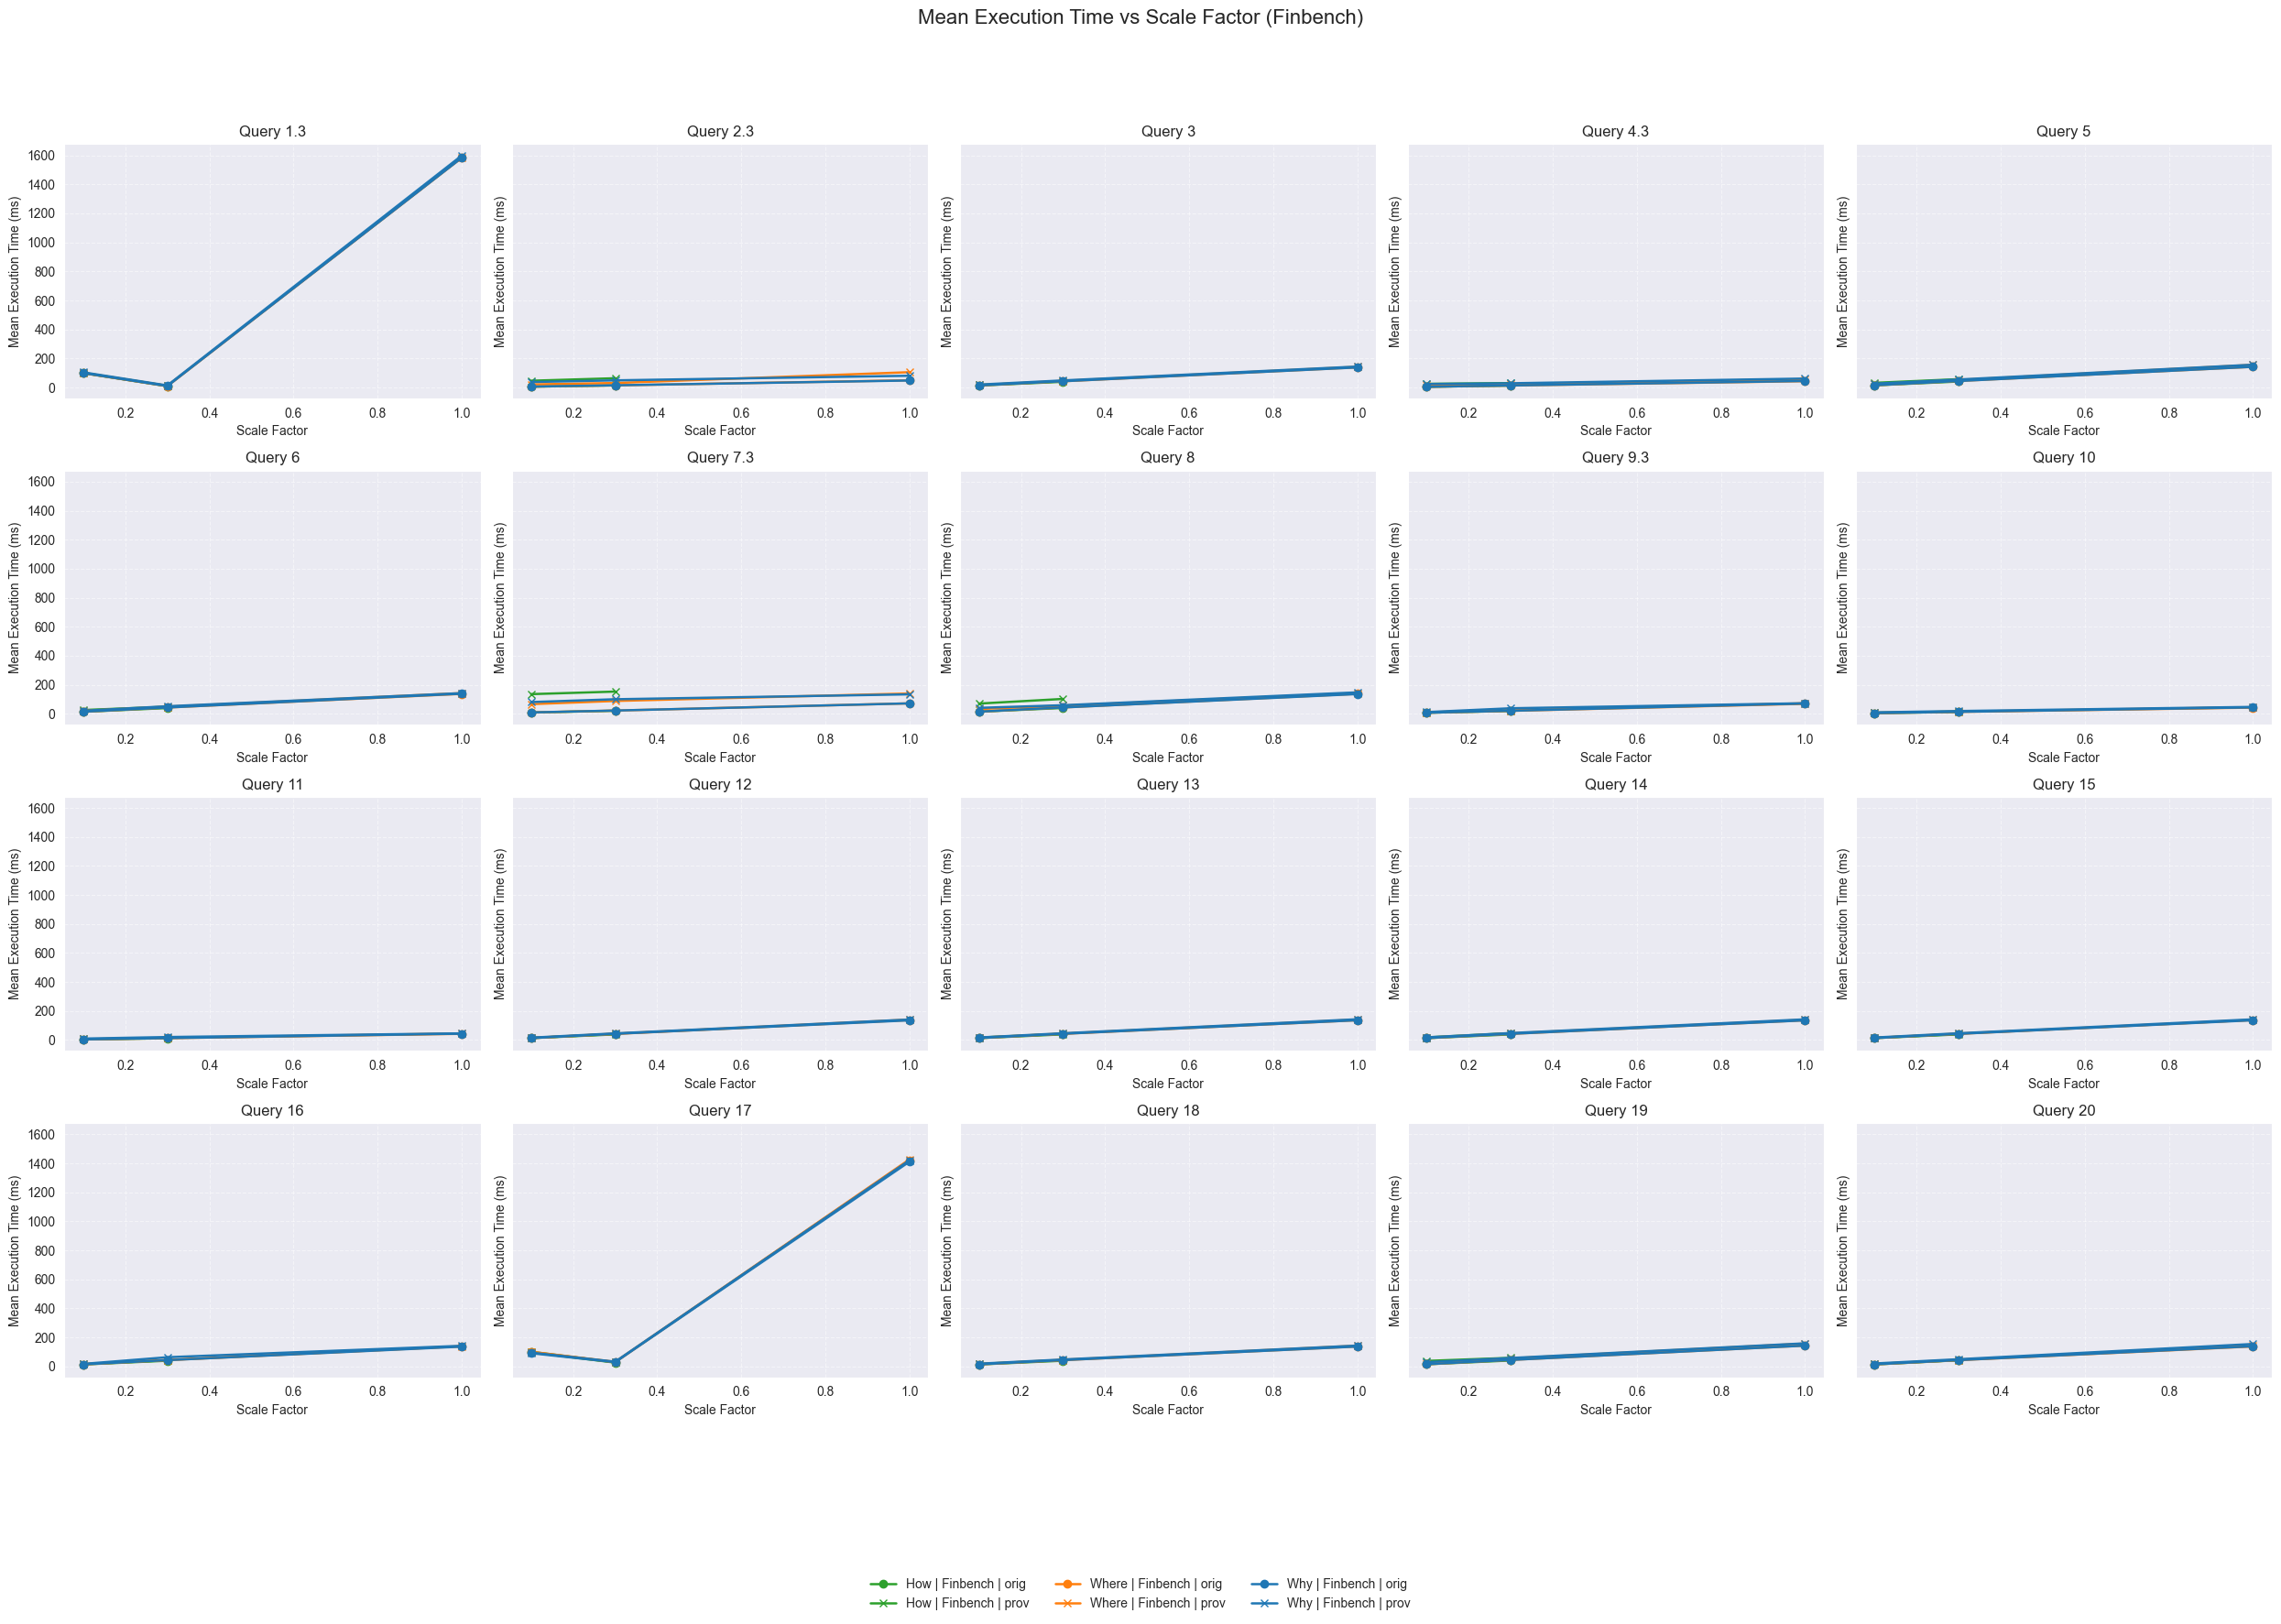

In [27]:
files = [
    "2026-01-25_naive_latency.csv",
    "2026-01-25_fnb_0.3_naive_latency.csv",
    "2026-01-25_fnb_1_naive_latency.csv"
]

df = pd.concat(
    [pd.read_csv(os.path.join("result/metrics", f)) for f in files],
    ignore_index=True
)

df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(
    r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_'
)

# Keep only integers or .3 queries
df = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]

# Pretty dataset names
dataset_map = {"finbench": "Finbench", "snb": "SNB"}
df["dataset"] = df["dataset"].map(dataset_map).fillna(df["dataset"])

agg = (
    df.groupby(
        ["query_id", "provModel", "dataset", "scaleFactor", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean", "mean"))
)

def sort_key(q):
    return (int(q.split(".")[0]), q)

query_ids = sorted(agg["query_id"].unique(), key=sort_key)

prov_colors = {
    "Why": "#1f77b4",
    "Where": "#ff7f0e",
    "How": "#2ca02c"
}

marker_map = {
    "orig": "o",
    "prov": "x"
}

n_cols = 5
n_rows = int(np.ceil(len(query_ids) / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True
)
axes = axes.flatten()

for ax, qid in zip(axes, query_ids):
    sub = agg[agg["query_id"] == qid]

    for (provModel, dataset, query_type), g in sub.groupby(
            ["provModel", "dataset", "query_type"]
    ):
        g = g.sort_values("scaleFactor")

        ax.plot(
            g["scaleFactor"],                 # ✅ numeric x → real lines
            g["mean_exec_time"],
            color=prov_colors.get(provModel, "black"),
            marker=marker_map[query_type],
            linestyle="-",
            linewidth=1.8,
            markersize=6,
            label=f"{provModel} | {dataset} | {query_type}"
        )

    ax.set_title(f"Query {qid}")
    ax.set_xlabel("Scale Factor")
    ax.set_ylabel("Mean Execution Time (ms)")
    ax.grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots
for ax in axes[len(query_ids):]:
    fig.delaxes(ax)

#Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.suptitle("Mean Execution Time vs Scale Factor (Finbench)", fontsize=16, y=1.02)

# Save
output_dir = "./result/plots"
os.makedirs(output_dir, exist_ok=True)
out = f"{output_dir}/mean_execution_time_lines.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved plot to {out}")

plt.show()


TypeError: unhashable type: 'list'

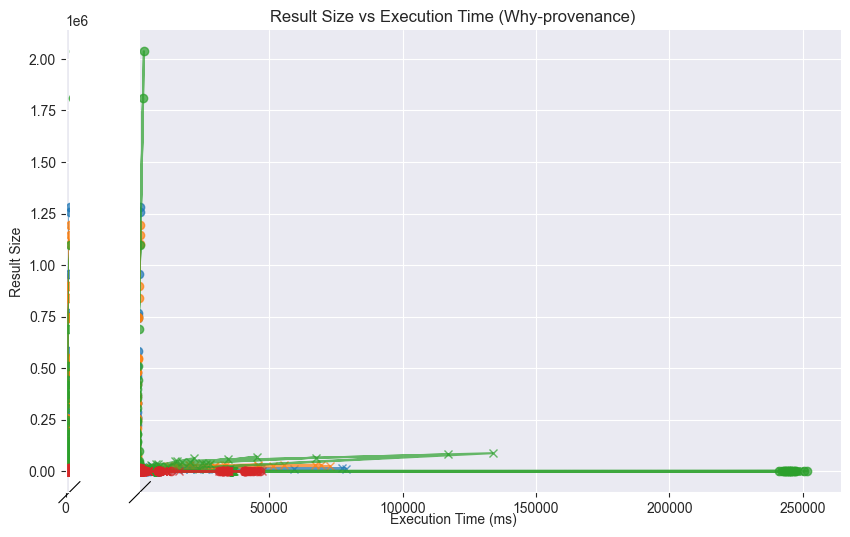

In [42]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes

# -------------------------
# 1️⃣ Read and combine files
# -------------------------
files = [
    "2026-01-25_naive_latency.csv",
    "2026-01-25_fnb_0.3_naive_latency.csv",
    "2026-01-25_fnb_1_naive_latency.csv",
    "2026-01-25_snb_1_naive_latency.csv"
]

df = pd.concat([pd.read_csv(os.path.join("result/metrics", f)) for f in files], ignore_index=True)

# -------------------------
# 2️⃣ Extract query info
# -------------------------
df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_[^-]+-(\d+(?:\.\d+)*)_')

dataset_mapping = {"finbench": "Finbench", "snb": "SNB"}
df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])
df = df.dropna(subset=["resultSize", "mean", "provModel", "query_type", "dataset", "scaleFactor"])

# -------------------------
# 3️⃣ Prepare colors and markers
# -------------------------
combos = df[["dataset","scaleFactor"]].drop_duplicates().reset_index(drop=True)
colors = plt.cm.tab10.colors
combo_colors = {tuple(row): colors[i % len(colors)] for i, row in combos.iterrows()}
marker_map = {"orig": "o", "prov": "x"}

output_dir = "./result/plots"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# 4️⃣ Plot per provenance model with broken x-axis
# -------------------------
for prov_model in ["Why", "Where", "How"]:
    sub = df[df["provModel"] == prov_model]
    if sub.empty:
        continue

    # Split x-axis: low exec times vs high exec times
    split_low = sub["mean"].quantile(0.9)
    split_high = sub["mean"].max() * 1.05

    # Create figure first
    fig = plt.figure(figsize=(10,6))

    # Create broken axes using the figure
    bax = brokenaxes(
        xlims=((0, split_low), (split_low*1.1, split_high)),
        hspace=.05,
        figure=fig
    )

    # Plot each dataset+scaleFactor and query_type
    for (dataset, scale), g in sub.groupby(["dataset","scaleFactor"]):
        color = combo_colors[(dataset, scale)]
        for query_type, gg in g.groupby("query_type"):
            bax.plot(
                gg["mean"],       # x-axis execution time
                gg["resultSize"], # y-axis result size
                marker=marker_map[query_type],
                linestyle='-',    # line connecting points
                color=color,
                alpha=0.7,
                label=f"{dataset}-SF{scale} ({query_type})"
            )

    bax.set_xlabel("Execution Time (ms)")
    bax.set_ylabel("Result Size")
    plt.title(f"Result Size vs Execution Time ({prov_model}-provenance)")

    # Shared legend
    handles, labels = bax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='lower center', ncol=3, frameon=False)

    plt.tight_layout()
    filename = f"{output_dir}/result_size_vs_exec_time_{prov_model}_broken.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")
